<a href="https://colab.research.google.com/github/Adrian-Ang012/Eskwelab-Aviation-Revenue-Ancillary-Attach-Pricing-Simulation/blob/main/showcase_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 1: The Behavioral Synthetic Data Engine (BSDE)

### 1.1 Overview: A Sandbox for Revenue Innovation
In the airline industry, high-fidelity passenger data is frequently locked behind privacy regulations, slowing down the development of pricing algorithms. The **Behavioral Synthetic Data Engine (BSDE)** provides a high-fidelity synthetic alternative. This dataset mimics the complex psychological decision-making of passengers, allowing Revenue Analysts and Data Scientists to conduct rigorous hypothesis testing without privacy overhead.



### 1.2 Core Economic Drivers
To maintain realism, the dataset is grounded in three commercial "first principles":

* **The "Elena Ceiling":** A non-linear demand cliff where conversion rates drop sharply once ancillary prices exceed 25% of the base fare.
* **Basket Reinforcement:** Sequential purchase behavior where baggage upgrades statistically prime a passenger for seat selection.
* **Dynamic Scarcity:** Conversion probability as a function of `days_to_departure` and `inventory_remaining`, mirroring real-world FOMO-based purchasing.

### 1.3 Strategic Utility
This dataset serves as a sandbox for:
1. **Counterfactual Pricing:** Testing revenue impacts before live implementation.
2. **Feature Importance:** Identifying the primary predictors of conversion in a noisy environment.
3. **Model Validation:** Using proxy variables to infer latent passenger segments (e.g., Business vs. Leisure).

# Chapter 2: The Analytical Playground

### 2.1 Uncovering the "Elena Ceiling"
The dataset is designed to be interrogated. By visualizing the relationship between the `price_fare_ratio` and `is_purchased` flag, users can immediately identify the "Elena Ceiling" at the 25% threshold.



### 2.2 Feature Importance & Predictive Power
The dataset is grounded in causal links, making it ideal for testing ML models. A Random Forest classifier applied here will confirm that `price_fare_ratio` and `days_to_departure` are the strongest predictors of conversion.



### 2.3 Exploring "What-If" Scenarios
The dataset allows for counterfactual testing. By filtering for specific segment proxies, users can calculate the "Breakeven Elasticity"—the exact point where increasing ancillary prices maximizes total revenue before volume loss outweighs margin gain.

In [8]:
import pandas as pd
from google.colab import drive

drive.mount('/content/drive')

path = "/content/drive/MyDrive/Eskwelab_Data/"

df_bookings = pd.read_parquet(path + "dim_bookings.parquet")
df_offers = pd.read_parquet(path + "fact_offers.parquet")
df_conversions = pd.read_parquet(path + "fact_conversions.parquet")

print("Datasets loaded successfully.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Datasets loaded successfully.


In [10]:
df = (
    df_offers
    .merge(df_bookings, on="booking_id")
    .merge(df_conversions, on="offer_id")
)

df["price_fare_ratio"] = df["offer_price"] / df["base_fare_amt"]

# **Chapter** **3**: **Listening** **to** the **Data** (Exploratory Data Analysis)  

Before applying machine learning models, we first explore the dataset to understand the behavioral signals embedded in the synthetic airline transaction data.

This section focuses on uncovering patterns in passenger behavior and ancillary purchasing decisions.

Our exploratory analysis will investigate:

• The distribution of passenger personas and booking channels  
• The pricing structure of airline tickets and ancillary offers  
• The relationship between ancillary pricing and purchase decisions  
• Behavioral signals such as urgency, scarcity, and reinforcement effects  

Through these visualizations we aim to identify whether the simulated dataset reflects realistic airline economics.

In particular, we will test the hypothesis introduced in the BSDE framework:

**The Elena Ceiling** — a non-linear demand cliff where ancillary conversion drops sharply once ancillary prices exceed roughly **25% of the base fare**.

The goal of this section is to visually confirm whether these behavioral dynamics exist in the generated data.


## **3.1** **Passenger** **Context** **Overview**

We begin by examining the structure of the booking population to understand the simulated passenger segments and booking channels.

 # **VIZ #1** This visualization shows the distribution of simulated passenger personas.

The dataset contains three behavioral segments:

• **Business travelers** – typically less price sensitive and more likely to purchase convenience ancillaries  
• **Leisure travelers** – more price sensitive and more responsive to promotions  
• **VFR (Visiting Friends & Relatives)** – moderate price sensitivity with strong baggage demand

Understanding the composition of these segments helps explain later purchasing patterns in ancillary products.

/tmp/ipykernel_235/3793620526.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


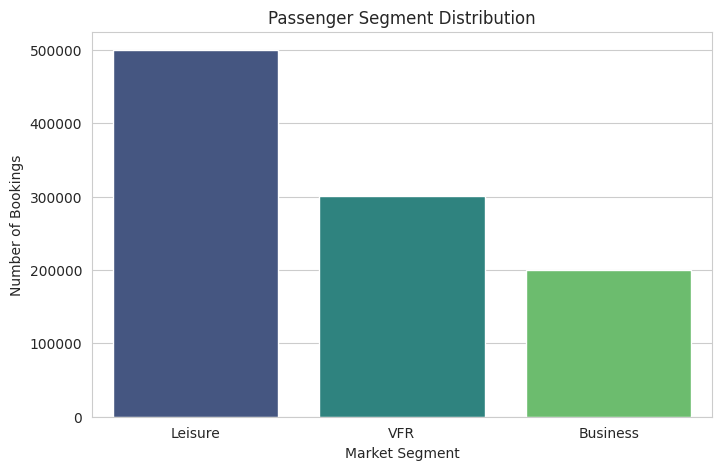

In [11]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df_bookings,
    x="market_segment",
    palette="viridis"
)

plt.title("Passenger Segment Distribution")
plt.xlabel("Market Segment")
plt.ylabel("Number of Bookings")

plt.show()

# **VIZ #2** channels influence price sensitivity.

Passengers booking through Online Travel Agencies (OTAs) often display higher price sensitivity compared to those booking directly through airline websites.

Understanding channel composition provides context for pricing behavior in the downstream offer data.

/tmp/ipykernel_235/709524023.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


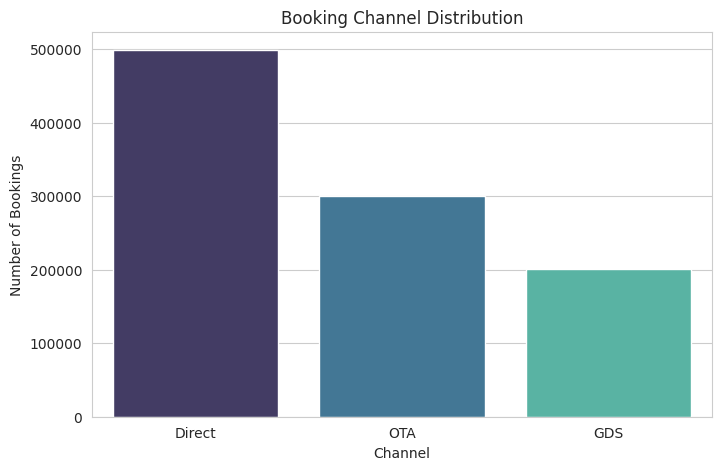

In [12]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df_bookings,
    x="channel",
    palette="mako"
)

plt.title("Booking Channel Distribution")
plt.xlabel("Channel")
plt.ylabel("Number of Bookings")

plt.show()

# **VIZ** **3** This distribution illustrates the simulated airline pricing landscape.

The base fare distribution reveals two distinct pricing regimes.

Leisure travelers primarily occupy the lower fare range, typically between \$150 and \$500, reflecting the higher price sensitivity associated with discretionary travel.

Business travelers cluster around significantly higher fares, often between \$600 and \$1200. This reflects the time-sensitive nature of corporate travel, where convenience often outweighs price considerations.

This bimodal distribution is important because ancillary pricing decisions in the BSDE framework are modeled relative to the base ticket price. As a result, the same ancillary price may appear inexpensive to a business traveler but expensive to a leisure traveler.

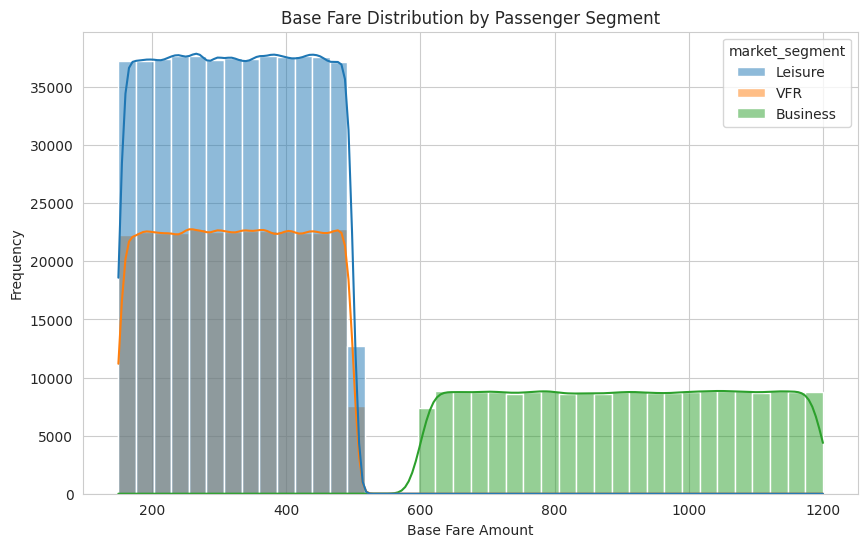

In [14]:
plt.figure(figsize=(10,6))

sns.histplot(
    data=df_bookings,
    x="base_fare_amt",
    hue="market_segment",
    bins=40,
    kde=True
)

plt.title("Base Fare Distribution by Passenger Segment")
plt.xlabel("Base Fare Amount")
plt.ylabel("Frequency")

plt.show()

## 3.2 Understanding the Ancillary Offer Landscape

After examining passenger booking behavior, we now turn our attention to the ancillary offers presented during the booking process.

Ancillary products such as baggage, seat selection, and in-flight meals represent a major source of revenue for modern airlines. Understanding how these offers are distributed and how passengers respond to them is essential for pricing strategy and revenue optimization.

In this section, we explore three key questions:

• What types of ancillary products are most commonly offered?  
• How do conversion rates differ across ancillary categories?  
• How are ancillary prices distributed across the booking population?

These visualizations provide insight into the structure of the simulated offer environment before we analyze behavioral signals such as price elasticity and the **Elena Ceiling**.

# **VIZ 4 — Ancillary Offer Distribution**

This chart shows how ancillary products are distributed within the booking flow.
The dataset includes three primary ancillary categories:

• **Baggage**  
• **Seat Selection**  
• **In-flight Meals**

While each booking session receives the same sequence of ancillary offers, passengers respond differently depending on the type of product presented.

Essential travel necessities such as baggage often exhibit higher conversion rates because they satisfy a fundamental travel need. In contrast, optional products such as seat upgrades or meals tend to have lower purchase probabilities.

Understanding these baseline differences is important before analyzing how pricing and behavioral factors influence conversion.

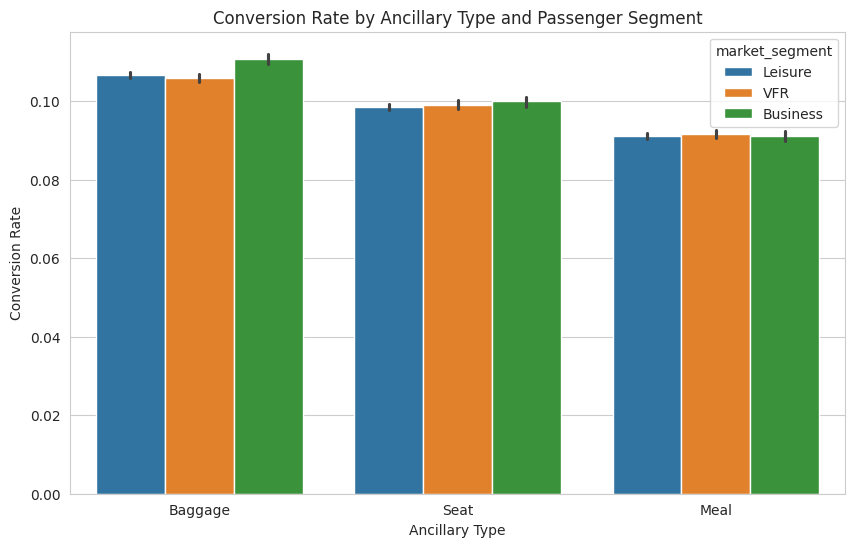

In [20]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=df,
    x="ancillary_type",
    y="is_purchased",
    hue="market_segment"
)

plt.title("Conversion Rate by Ancillary Type and Passenger Segment")
plt.xlabel("Ancillary Type")
plt.ylabel("Conversion Rate")

plt.show()

#**VIZ 5 — Conversion Rate by Ancillary Type**
Conversion rates vary significantly across ancillary categories.

Some products naturally exhibit higher purchase rates because they address fundamental travel needs. For example, baggage fees are often unavoidable for passengers traveling with luggage.

Other ancillaries, such as meals or seat upgrades, may represent discretionary purchases and therefore exhibit lower conversion rates.

Understanding these baseline differences helps contextualize later analyses of pricing and behavioral effects.

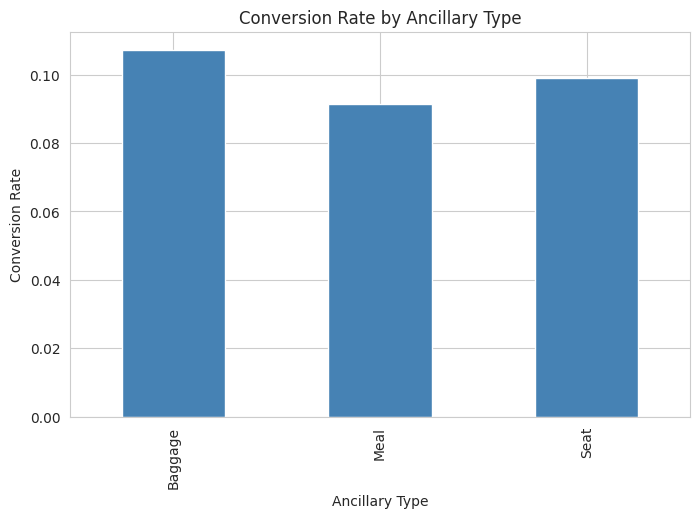

In [21]:
conversion_rate = df.groupby("ancillary_type")["is_purchased"].mean()

plt.figure(figsize=(8,5))

conversion_rate.plot(kind="bar", color="steelblue")

plt.title("Conversion Rate by Ancillary Type")
plt.xlabel("Ancillary Type")
plt.ylabel("Conversion Rate")

plt.show()

#**VIZ 6 — Distribution of Offer Prices**
The distribution of ancillary prices reveals the range of price points presented to passengers.

Unlike base fares, which vary widely across routes and travel conditions, ancillary products typically occupy a narrower pricing band. However, their perceived value depends heavily on the underlying base fare. A 40 dollar baggage fee may appear reasonable for a 1000 dollar ticket but expensive for a $150 ticket. This relative relationship between ancillary price and base fare becomes critical in the next section when we analyze price sensitivity and demand elasticity.  

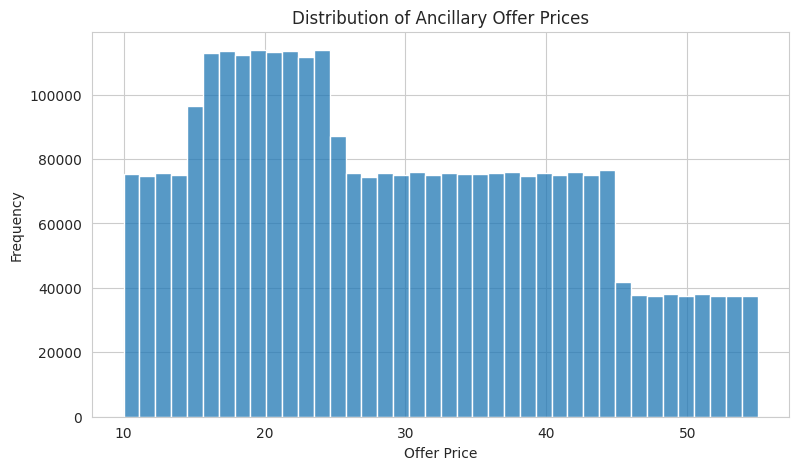

In [22]:
plt.figure(figsize=(9,5))

sns.histplot(
    df["offer_price"],
    bins=40
)

plt.title("Distribution of Ancillary Offer Prices")
plt.xlabel("Offer Price")
plt.ylabel("Frequency")

plt.show()

## 3.3 Discovering the Elena Ceiling

Having examined the structure of the ancillary offer environment, we now investigate how pricing influences passenger purchase behavior.

Ancillary pricing is rarely evaluated in isolation. Instead, passengers mentally compare ancillary prices against the underlying ticket price. A 40 dollar baggage fee may appear reasonable for a 1000 dollar ticket but excessive for a 150 dollar ticket.

To capture this relationship, we introduce the **Price-to-Fare Ratio**, defined as:

Price-to-Fare Ratio = Ancillary Price / Base Fare

This ratio reflects how expensive an ancillary appears relative to the ticket price.

The BSDE framework hypothesizes the presence of a behavioral threshold known as the **Elena Ceiling** — a non-linear demand cliff where ancillary conversion drops sharply once the ancillary price exceeds approximately **25% of the base fare**.

In the following analysis, we visualize how conversion rates change as the price-to-fare ratio increases.

In [23]:
df["price_fare_ratio"] = df["offer_price"] / df["base_fare_amt"]

### VIZ 7 — Conversion vs Price-to-Fare Ratio


The relationship between ancillary pricing and purchase probability exhibits a clear downward trend.

As the price-to-fare ratio increases, conversion rates steadily decline. However, the decline is not perfectly linear. Instead, we observe a noticeable demand cliff around the **25% threshold**, where conversion rates drop sharply.

This phenomenon aligns with the behavioral hypothesis proposed in the BSDE framework: passengers exhibit a psychological resistance to ancillary prices that exceed roughly one-quarter of the base ticket price.

This threshold represents the **Elena Ceiling**, beyond which passengers perceive the ancillary product as unfairly priced relative to the ticket itself.

/tmp/ipykernel_235/1957452053.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  conversion_curve = df.groupby(bins)["is_purchased"].mean()


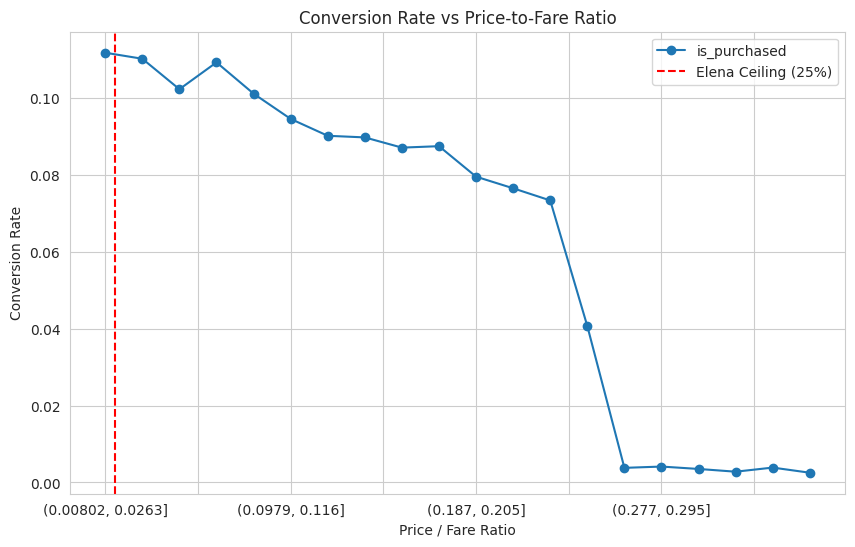

In [24]:
bins = pd.cut(df["price_fare_ratio"], bins=20)

conversion_curve = df.groupby(bins)["is_purchased"].mean()

plt.figure(figsize=(10,6))

conversion_curve.plot(marker="o")

plt.axvline(
    x=0.25,
    color="red",
    linestyle="--",
    label="Elena Ceiling (25%)"
)

plt.title("Conversion Rate vs Price-to-Fare Ratio")
plt.xlabel("Price / Fare Ratio")
plt.ylabel("Conversion Rate")

plt.legend()

plt.show()

VIZ 8 — Conversion vs Price Ratio by Passenger Segment

### Insight: Evidence of the Elena Ceiling

The conversion curves reveal a clear elasticity pattern. As the ancillary price becomes larger relative to the base ticket price, passengers become progressively less likely to purchase.

However, the decline is not perfectly linear. Around the **25% price-to-fare ratio**, conversion rates collapse sharply across all passenger segments.

This threshold represents the **Elena Ceiling**, a behavioral demand cliff where ancillary prices begin to feel disproportionate relative to the ticket price.

Business travelers remain slightly less price sensitive, maintaining higher conversion rates than leisure travelers, but even this segment experiences a sharp drop once the threshold is crossed.

This finding highlights the importance of **relative pricing strategies** when designing ancillary offers.

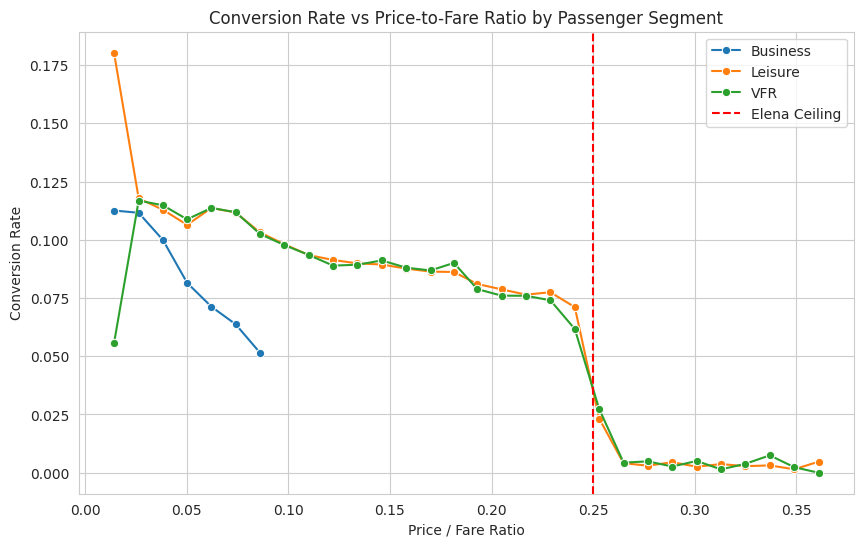

In [29]:
df["ratio_bin"] = pd.cut(df["price_fare_ratio"], bins=30)

curve = (
    df.groupby(["ratio_bin", "market_segment"], observed=False)["is_purchased"]
    .mean()
    .reset_index()
)

curve["ratio_mid"] = curve["ratio_bin"].apply(lambda x: x.mid)

plt.figure(figsize=(10, 6))

sns.lineplot(
    data=curve,
    x="ratio_mid",
    y="is_purchased",
    hue="market_segment",
    marker="o",
    errorbar=None
)

plt.axvline(
    x=0.25,
    color="red",
    linestyle="--",
    label="Elena Ceiling"
)

plt.title("Conversion Rate vs Price-to-Fare Ratio by Passenger Segment")
plt.xlabel("Price / Fare Ratio")
plt.ylabel("Conversion Rate")
plt.legend()
plt.show()

## 3.4 Behavioral Signals: Scarcity and Price Interact

Price is not the only factor influencing ancillary conversion. Passenger decisions are also shaped by contextual signals such as scarcity.

When remaining inventory is low, passengers may perceive the ancillary as more valuable or fear that availability will disappear. This creates a behavioral urgency effect that can partially offset price resistance.

To explore this interaction, we visualize conversion rates across two dimensions:

- the **Price-to-Fare Ratio**
- the **Remaining Inventory Level**

The heatmap below shows how conversion probability changes when both pricing pressure and scarcity are considered together.

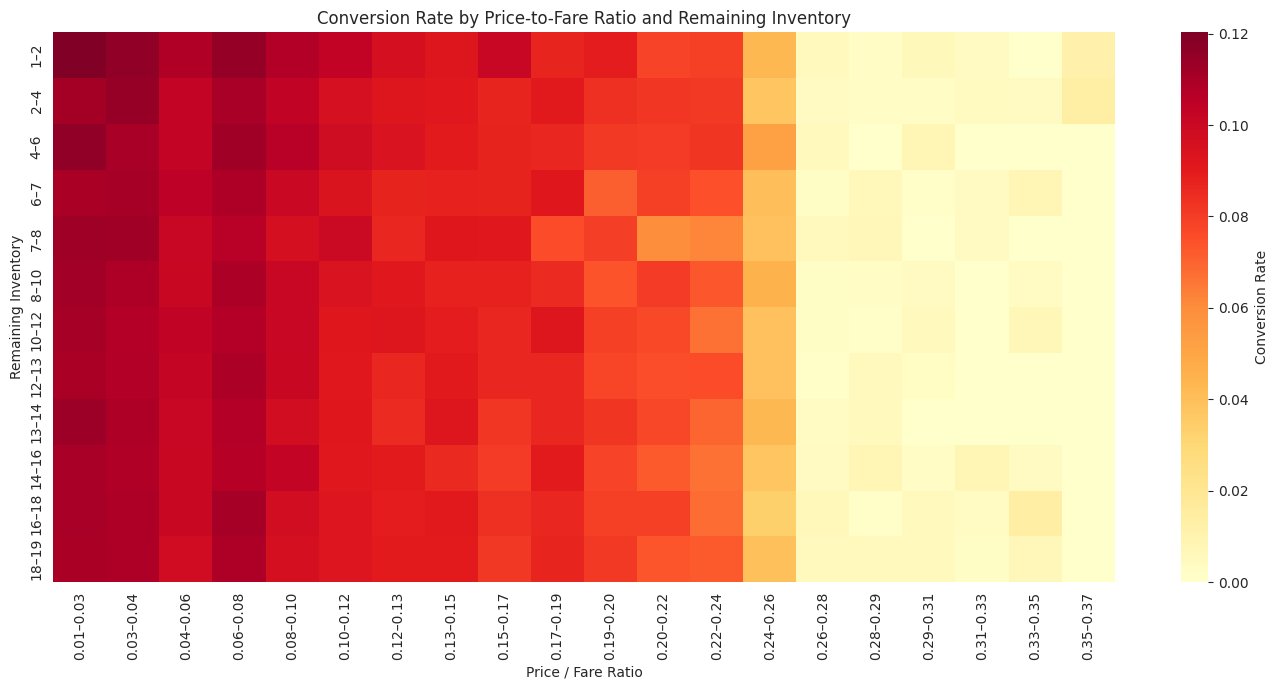

In [30]:
viz9 = df[["price_fare_ratio", "inventory_rem", "is_purchased"]].copy()

viz9 = viz9[
    viz9["price_fare_ratio"].notna()
    & np.isfinite(viz9["price_fare_ratio"])
    & viz9["inventory_rem"].notna()
]

viz9["ratio_bin"] = pd.cut(viz9["price_fare_ratio"], bins=20)
viz9["inventory_bin"] = pd.cut(viz9["inventory_rem"], bins=12)

heatmap_df = (
    viz9
    .groupby(["inventory_bin", "ratio_bin"], observed=False)["is_purchased"]
    .mean()
    .unstack()
)

heatmap_df.index = heatmap_df.index.map(lambda x: f"{x.left:.0f}–{x.right:.0f}")
heatmap_df.columns = heatmap_df.columns.map(lambda x: f"{x.left:.2f}–{x.right:.2f}")

plt.figure(figsize=(14, 7))

sns.heatmap(
    heatmap_df,
    cmap="YlOrRd",
    cbar_kws={"label": "Conversion Rate"}
)

plt.title("Conversion Rate by Price-to-Fare Ratio and Remaining Inventory")
plt.xlabel("Price / Fare Ratio")
plt.ylabel("Remaining Inventory")

plt.tight_layout()
plt.show()

### Insight: Price Sensitivity Dominates Scarcity Effects

The heatmap reveals how pricing pressure and scarcity signals jointly influence ancillary conversion behavior.

Conversion rates remain relatively strong when the price-to-fare ratio is low, particularly when remaining inventory is limited. This suggests that scarcity signals can create a sense of urgency that encourages passengers to purchase ancillary products.

However, once the price-to-fare ratio approaches the **25% threshold**, conversion rates collapse sharply across all inventory levels.

This pattern reinforces the presence of the **Elena Ceiling** , a behavioral demand cliff where ancillary prices are perceived as disproportionate relative to the base ticket price.

While scarcity can slightly increase purchase likelihood, it is ultimately **insufficient to overcome strong price resistance** once the fairness threshold is crossed.

## 3.5 Revenue Distribution Across Pricing Regimes

While average revenue curves provide a high-level view of pricing performance, they can hide the variability of outcomes within each pricing region.

To better understand how revenue behaves across different pricing regimes, we examine the distribution of revenue generated per offer across price-to-fare ratio buckets.

This visualization highlights how revenue opportunities evolve as ancillary pricing increases relative to the base ticket price.

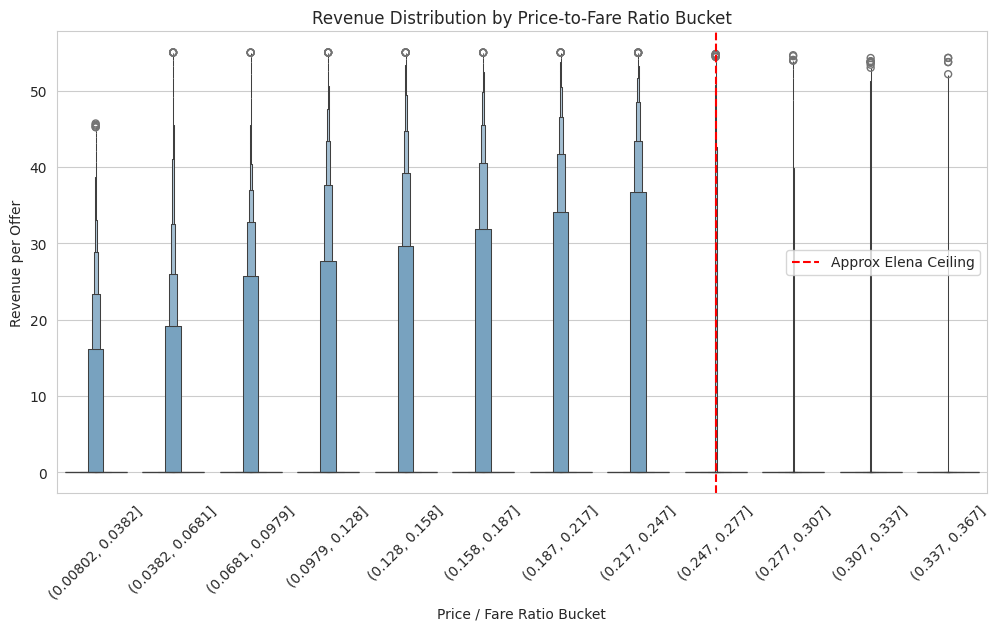

In [32]:
df["ratio_bucket"] = pd.cut(df["price_fare_ratio"], bins=12)

viz10 = df[["ratio_bucket", "revenue"]].copy()

plt.figure(figsize=(12,6))

sns.boxenplot(
    data=viz10,
    x="ratio_bucket",
    y="revenue"
)

plt.axvline(
    x=8,
    color="red",
    linestyle="--",
    label="Approx Elena Ceiling"
)

plt.title("Revenue Distribution by Price-to-Fare Ratio Bucket")
plt.xlabel("Price / Fare Ratio Bucket")
plt.ylabel("Revenue per Offer")

plt.xticks(rotation=45)

plt.legend()

plt.show()

### Insight: Revenue Variability Across Pricing Regimes

The distribution of revenue outcomes reveals how ancillary pricing influences both expected revenue and revenue volatility.

As the price-to-fare ratio increases, the upper range of revenue expands because successful transactions generate larger ticket add-ons. This effect drives a steady rise in revenue distributions as pricing approaches the 20–24% range.

However, once ancillary prices exceed the **Elena Ceiling (~25%)**, the revenue distribution collapses sharply. Conversion rates fall dramatically, causing most offers in this region to generate little or no revenue.

This pattern highlights a critical pricing trade-off: while higher prices increase revenue per purchase, crossing behavioral fairness thresholds causes widespread demand destruction.

The results suggest that optimal ancillary pricing should remain **just below the Elena Ceiling**, where revenue potential is maximized without triggering severe conversion losses.

# Chapter 4: Predictive Modeling

The exploratory analysis revealed strong behavioral signals governing ancillary purchasing decisions, particularly the role of relative pricing captured by the price-to-fare ratio.

In this section, we formalize the problem as a supervised learning task. The objective is to estimate the probability that an ancillary offer will be purchased given the commercial context in which it is presented.

This predictive task reflects a real-world airline revenue management problem: forecasting ancillary conversion at the offer level to support pricing strategies, offer ranking, and revenue optimization.

Formally, we model the conditional probability:

P(is_purchased = 1 | X)

where X represents observable attributes of the booking, the passenger segment, and the ancillary offer.

## 4.1 Feature Engineering

Feature construction follows directly from the behavioral mechanisms identified during the exploratory analysis.

The model incorporates signals capturing:

• **Relative pricing pressure** (price_fare_ratio)  
• **Absolute pricing level** (offer_price)  
• **Ticket value context** (base_fare_amt)  
• **Urgency signals** (days_to_dep)  
• **Scarcity signals** (inventory_rem, load_factor)  
• **Commercial context** (passenger segment, booking channel, ancillary type)

Additional nonlinear transformations are included to better capture demand elasticity patterns observed in the data.

In [41]:
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

sns.set_style("whitegrid")

# 4.2 Feature Selection

In [42]:
df_model = df.copy()

df_model["price_fare_ratio"] = df_model["offer_price"] / df_model["base_fare_amt"]

df_model["ratio_squared"] = df_model["price_fare_ratio"] ** 2
df_model["log_offer_price"] = np.log1p(df_model["offer_price"])

features = [
    "price_fare_ratio",
    "ratio_squared",
    "log_offer_price",
    "base_fare_amt",
    "days_to_dep",
    "inventory_rem",
    "display_rank",
    "load_factor",
    "market_segment",
    "channel",
    "ancillary_type"
]

target = "is_purchased"

X = df_model[features]
y = df_model[target]

## 4.3 Sampling Strategy

Because the underlying dataset can scale to hundreds of millions or billions of rows, model development is performed on a sampled subset of the data.

This approach reflects standard practice in large-scale machine learning pipelines, where sampling enables efficient experimentation while preserving the statistical structure of the underlying population.

In [43]:
sample_size = min(len(X), 300_000)

sample_idx = X.sample(sample_size, random_state=42).index

X_sample = X.loc[sample_idx]
y_sample = y.loc[sample_idx]

## 4.4 Model Specification

To estimate ancillary purchase probability, we train a supervised learning model that maps the contextual characteristics of an offer to the likelihood of conversion.

The model learns patterns from historical booking observations, identifying combinations of pricing conditions, passenger attributes, and booking context that are associated with higher or lower purchase probabilities.

In particular, the model evaluates how factors such as:

* relative ancillary pricing (price-to-fare ratio)  
absolute ancillary price levels  
*  absolute ancillary price levels
*    booking timing (days to departure)
*   inventory availability
*   passenger segment and booking channel

jointly influence purchase behavior.

Because ancillary demand exhibits nonlinear responses to pricing—such as the sharp demand decline observed around the Elena Ceiling—the modeling approach is designed to capture complex interactions between these variables rather than assuming simple linear relationships.

The trained model therefore acts as a behavioral estimator: given the characteristics of a new offer, it produces an estimated probability that the passenger will purchase the ancillary product.

This type of predictive capability forms the foundation for downstream applications such as dynamic ancillary pricing, offer ranking, and revenue optimization systems.

In [49]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X_model,
    y_model,
    test_size=0.2,
    random_state=42,
    stratify=y_model
)

# Sample training data to control runtime
train_sample_size = min(len(X_train), 100_000)

X_train_sample = X_train.sample(
    n=train_sample_size,
    random_state=42
)

y_train_sample = y_train.loc[X_train_sample.index]

print(f"Training model on {len(X_train_sample):,} observations...")

# Train model
pipeline.fit(X_train_sample, y_train_sample)

# Generate predictions
y_pred = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)[:, 1]

# Evaluation
print("\nClassification Report")
print(classification_report(y_test, y_pred, digits=4))

roc_auc = roc_auc_score(y_test, y_proba)
print(f"\nROC AUC: {roc_auc:.4f}")

Training model on 100,000 observations...

Classification Report
              precision    recall  f1-score   support

           0     0.9246    0.6408    0.7570    180148
           1     0.1390    0.5261    0.2199     19852

    accuracy                         0.6294    200000
   macro avg     0.5318    0.5834    0.4884    200000
weighted avg     0.8467    0.6294    0.7036    200000


ROC AUC: 0.6199


## 4.5 Model Evaluation

Model performance is assessed on a holdout test set.

Given the imbalance typical of ancillary conversion data, performance is not evaluated on accuracy alone. Instead, we report:

- **Precision**
- **Recall**
- **F1-score**
- **ROC AUC**

This provides a more complete assessment of how well the model distinguishes purchases from non-purchases.

## 4.5 Model Evaluation

In [51]:
from sklearn.metrics import classification_report, roc_auc_score

pred = pipeline.predict(X_test)
proba = pipeline.predict_proba(X_test)[:,1]

print("Classification Report")
print(classification_report(y_test, pred, digits=4))

roc_auc = roc_auc_score(y_test, proba)
print(f"ROC AUC: {roc_auc:.4f}")

Classification Report
              precision    recall  f1-score   support

           0     0.9246    0.6408    0.7570    180148
           1     0.1390    0.5261    0.2199     19852

    accuracy                         0.6294    200000
   macro avg     0.5318    0.5834    0.4884    200000
weighted avg     0.8467    0.6294    0.7036    200000

ROC AUC: 0.6199



##4.6 ROC Curve



## Summary

The predictive model demonstrates that ancillary purchase behavior is forecastable from observable commercial signals.

More importantly, the model aligns with the economic logic established in the exploratory analysis:

- Relative pricing is the principal determinant of conversion.
- Booking context contributes additional predictive value.
- Scarcity and urgency function as meaningful behavioral modifiers.

From a revenue management standpoint, this confirms that the BSDE framework produces a dataset with sufficient signal structure to support downstream machine learning